In [2]:
import numpy as np
import pandas as pd

# Run the notebook from the repository root so this path resolves.
ufo = pd.read_csv("data/raw/ufos.csv")
ufo.head()

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700.0,45 minutes,This event took place in early fall around 194...,4/27/2004,29.883056,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200.0,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.384210,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20.0,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.200000,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20.0,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.978333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900.0,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.418056,-157.803611


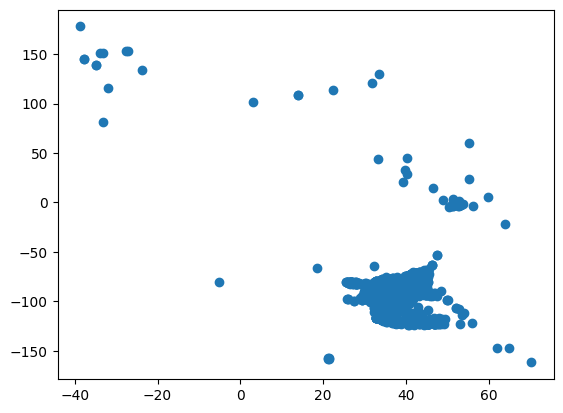

In [3]:
ufo_trimmed = ufo.iloc[:1000]

import matplotlib.pyplot as plt

plt.scatter(ufo_trimmed['latitude'], ufo_trimmed['longitude'])
plt.show()

In [4]:
# Create new dataframe w/ cleaner titles

ufos = pd.DataFrame({'Seconds': ufo['duration (seconds)'], 'Country': ufo['country'],'Latitude': ufo['latitude'],'Longitude': ufo['longitude']})

ufos['Country'].unique()

array(['us', nan, 'gb', 'ca', 'au', 'de'], dtype=object)

In [5]:
ufos.dropna(inplace=True) # get rid of NaN countries

ufos = ufos[(ufos['Seconds']>=1) & (ufos['Seconds'] <= 60)]
# have to use & because if we use 'and' it's ambiguous

ufos.head()

,Seconds,Country,Latitude,Longitude
2,20.0,gb,53.200000,-2.916667
3,20.0,us,28.978333,-96.645833
14,30.0,us,35.823889,-80.253611
23,60.0,us,45.582778,-122.352222
24,3.0,gb,51.783333,-0.783333


In [6]:
# Encode country labels for classification (LabelEncoder uses alphabetical order of codes).

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
ufos['Country'] = le.fit_transform(ufos['Country'])

ufos.head()

,Seconds,Country,Latitude,Longitude
2,20.0,3,53.200000,-2.916667
3,20.0,4,28.978333,-96.645833
14,30.0,4,35.823889,-80.253611
23,60.0,4,45.582778,-122.352222
24,3.0,3,51.783333,-0.783333


In [7]:
from sklearn.model_selection import train_test_split

training_features = ['Seconds', 'Latitude', 'Longitude']
target = 'Country'

X = ufos[training_features]
y = ufos[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [9]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print('Accuracy:', accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       0.85      0.46      0.60       250
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00       131
           4       0.97      1.00      0.98      4743

    accuracy                           0.97      5173
   macro avg       0.96      0.89      0.92      5173
weighted avg       0.97      0.97      0.97      5173

Accuracy: 0.9698434177459888


Obviously guessing country is not too hard, given that we inputted latitude and longitude.

Now that our model is trained, we want to pickle it, which is to package a python object

In [12]:
import pickle
from pathlib import Path

# Same path the Flask app loads: model/ufo-model.pkl
out = Path("model/ufo-model.pkl")
out.parent.mkdir(parents=True, exist_ok=True)
with open(out, "wb") as f:
    pickle.dump(model, f)

# Verify load (optional):
# with open(out, "rb") as f:
#     model = pickle.load(f)